In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import os
import math
from tqdm import tqdm

In [2]:
data_path = './data/preprocessed/'
# Load preprocessed data
train_dataset = torch.load(data_path+'train_dataset.pth', weights_only=False)
test_dataset = torch.load(data_path+'test_dataset.pth', weights_only=False)
# label_encoder = joblib.load(data_path+'label_encoder.pkl')

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [3]:
# Get all samples from train_dataset
X_train_all, y_train_all = train_dataset[:]  # or iterate through

# Assuming y is one-hot encoded: [1,0] for Success, [0,1] for Anomaly
# Find indices of success cases
success_indices = (y_train_all.argmax(dim=1) == 1).nonzero().squeeze()

# Extract only success cases
X_success = X_train_all[success_indices]
y_success = y_train_all[success_indices]

In [4]:
import torch.nn.functional as F

# 1. Normalize your embeddings first
X_success_normalized = [F.normalize(seq, dim=-1) for seq in X_success]

In [5]:
class NextEventDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, max_len=50):
        """
        sequences: list of tensors, each [seq_len, embed_dim]
        Handles LEFT-padded sequences (zeros at start)
        """
        self.sequences = sequences
        self.max_len = max_len
        self.pairs = []
        
        print(f"Processing {len(sequences)} sequences...")
        
        for seq_idx, seq in enumerate(sequences):
            # Find where actual data starts (first non-zero row)
            # Method 1: Check if any element is non-zero
            non_zero_mask = (seq != 0).any(dim=1)  # [seq_len]
            
            if not non_zero_mask.any():
                print(f"⚠️ Sequence {seq_idx} is all zeros, skipping")
                continue
                
            # Get actual start and end of data
            data_start = non_zero_mask.nonzero()[0, 0].item() if non_zero_mask.any() else 0
            data_end = non_zero_mask.nonzero()[-1, 0].item() + 1 if non_zero_mask.any() else len(seq)
            
            actual_data = seq[data_start:data_end]
            actual_len = len(actual_data)
            
            if actual_len < 2:
                continue  # Need at least 2 events for prediction
                
            # Create (context, target) pairs from ACTUAL data only
            for i in range(1, actual_len):
                context = actual_data[:i]  # All previous actual events
                target = actual_data[i]     # Next actual event
                
                # Truncate if too long
                if len(context) > max_len:
                    context = context[-max_len:]
                
                self.pairs.append((context, target))
                
            if seq_idx < 3:  # Debug first few
                print(f"Seq {seq_idx}: padded_len={len(seq)}, actual_len={actual_len}, pairs={actual_len-1}")
        
        print(f"Created {len(self.pairs)} training pairs")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        return self.pairs[idx]

In [6]:
def left_pad_collate(batch):
    """Left-pad sequences (zeros at start)"""
    contexts, targets = zip(*batch)
    
    # Get max length in this batch
    max_len = max(len(ctx) for ctx in contexts)
    embed_dim = contexts[0].shape[-1]
    batch_size = len(contexts)
    
    # Create left-padded batch
    padded = torch.zeros(batch_size, max_len, embed_dim)
    padding_mask = torch.ones(batch_size, max_len, dtype=torch.bool)
    
    for i, ctx in enumerate(contexts):
        ctx_len = len(ctx)
        start_idx = max_len - ctx_len  # Left padding
        padded[i, start_idx:] = ctx
        padding_mask[i, start_idx:] = False
    
    return padded, torch.stack(targets), padding_mask

In [7]:
dataset = NextEventDataset(X_success_normalized)
next_event_loader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True,
    collate_fn=left_pad_collate
)


Processing 11399 sequences...
Seq 0: padded_len=50, actual_len=30, pairs=29
Seq 1: padded_len=50, actual_len=36, pairs=35
Seq 2: padded_len=50, actual_len=22, pairs=21
Created 290772 training pairs


In [8]:
class NextEventTransformer(nn.Module):
    def __init__(self, embed_dim=384, num_heads=8, num_layers=6,
                 max_seq_len=50, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_seq_len = max_seq_len

        # learned positional embeddings
        self.pos_emb = nn.Parameter(
            torch.randn(1, max_seq_len, embed_dim) * 0.02
        )

        # encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            layer_norm_eps=1e-6
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # prediction head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2 * embed_dim),
            nn.GELU(),
            nn.Linear(2 * embed_dim, embed_dim),
        )

        self._init_weights()

    def _init_weights(self):
        for p in self.encoder.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, padding_mask=None):
        # x: (B, T, D)
        
        # Use provided mask or detect zeros
        if padding_mask is None:
            padding_mask = (x.sum(dim=-1) == 0)
        
        # Add positional embeddings
        x = x + self.pos_emb[:, :x.size(1)]
        x = x * (self.embed_dim ** 0.5)
        
        # Transformer
        enc = self.encoder(x, src_key_padding_mask=padding_mask)
        
        # Get last non-padding token
        lengths = (~padding_mask).sum(dim=1)
        idx = torch.clamp(lengths - 1, min=0)
        
        # Gather last hidden states
        b = x.size(0)
        last_h = enc[torch.arange(b), idx]
        
        # Predict next embedding
        return self.head(last_h)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NextEventTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

In [ ]:
warmup_steps = 500
base_lr = 5e-5
total_steps = len(next_event_loader) * 5
global_step = 0

# Save directory
save_dir = "models/transformer/checkpoints"
os.makedirs(save_dir, exist_ok=True)

# Track best model
best_loss = float('inf')
best_model_state = None
patience = 1  # Stop if loss doesn't improve for 2 epochs
patience_counter = 0

# Training loop
for epoch in range(5):
    model.train()
    pbar = tqdm(next_event_loader, desc=f"Epoch {epoch+1}", ncols=100)
    
    epoch_loss = 0
    num_batches = 0

    for batch_X, batch_y, padding_mask in pbar:
        global_step += 1

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        padding_mask = padding_mask.to(device)

        # ---- LR schedule ----
        if global_step < warmup_steps:
            lr = base_lr * (global_step / warmup_steps)
        else:
            progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
            progress = min(progress, 1.0)
            lr = base_lr * 0.5 * (1 + math.cos(math.pi * progress))

        for g in optimizer.param_groups:
            g["lr"] = lr

        # ---- forward ----
        pred = model(batch_X, padding_mask)
        pred_n = F.normalize(pred, dim=-1)
        tgt_n = F.normalize(batch_y, dim=-1)

        loss = 1 - (pred_n * tgt_n).sum(-1).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": lr})

    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    print(f"\nEpoch {epoch+1} completed. Average loss: {avg_epoch_loss:.4f}")
    
    # Check if this is the best model
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        best_model_state = model.state_dict().copy()  # Save best weights
        patience_counter = 0  # Reset patience
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, os.path.join(save_dir, "best_model.pth"))
        print(f"✅ New best model! Loss: {best_loss:.4f} (Cosine similarity: {1-best_loss:.4f})")
    else:
        patience_counter += 1
        print(f"⚠️  Loss didn't improve. Patience: {patience_counter}/{patience}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n🚨 Early stopping triggered! No improvement for {patience} epochs.")
        print(f"Best loss: {best_loss:.4f} at epoch {epoch+1-patience}")
        break

# Load the best model weights back
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model with loss: {best_loss:.4f}")

# Save final model (with best weights)
torch.save({
    'epoch': epoch,
    'global_step': global_step,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': best_loss,
}, os.path.join(save_dir, "final_model.pth"))

print(f"\n🏆 Training complete! Best cosine similarity: {1-best_loss:.4f}")
print(f"Models saved to: {save_dir}/")

In [10]:
checkpoint = torch.load("models/transformer/checkpoints/best_model.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [22]:
# Test on the SAME type of data you trained on
print("Testing on next_event_loader data (embeddings)...")

# Get a batch from next_event_loader
test_batch_X, test_batch_y, test_mask = next(iter(next_event_loader))
test_batch_X, test_batch_y, test_mask = test_batch_X.to(device), test_batch_y.to(device), test_mask.to(device)

# Calculate loss the SAME way as training
with torch.no_grad():
    pred = model(test_batch_X, test_mask)
    pred_n = F.normalize(pred, dim=-1)
    tgt_n = F.normalize(test_batch_y, dim=-1)
    
    test_loss = 1 - (pred_n * tgt_n).sum(-1).mean()
    test_similarity = 1 - test_loss.item()

print(f"Test loss: {test_loss.item():.6f}")
print(f"Test similarity: {test_similarity:.6f}")
print(f"Training loss was: {checkpoint['loss']:.6f}")
print(f"Should be similar!")

Testing on next_event_loader data (embeddings)...
Test loss: 0.228347
Test similarity: 0.771653
Training loss was: 0.064362
Should be similar!


In [11]:
def get_prediction_similarity(model, context, target):
    """Calculate cosine similarity between prediction and target"""
    device = next(model.parameters()).device
    
    # Prepare input
    if len(context) > model.max_seq_len:
        context = context[-model.max_seq_len:]
    
    if len(context) < model.max_seq_len:
        padded = torch.zeros((model.max_seq_len, context.shape[-1]), device=device)
        start_idx = model.max_seq_len - len(context)
        padded[start_idx:] = context.to(device)
        mask = torch.ones(model.max_seq_len, dtype=torch.bool, device=device)
        mask[start_idx:] = False
    else:
        padded = context.to(device)
        mask = torch.zeros(model.max_seq_len, dtype=torch.bool, device=device)
    
    # Predict
    with torch.no_grad():
        pred = model(padded.unsqueeze(0), mask.unsqueeze(0))  # [1, 384]
        pred_n = F.normalize(pred.squeeze(0), dim=-1)  # [384]
        target_n = F.normalize(target.to(device), dim=-1)  # [384]
        
        cos_sim = (pred_n * target_n).sum().item()
    
    return cos_sim

In [12]:
def test_anomaly_detection(model, test_dataset, threshold=0.7):
    """Test if low similarity catches Fail sequences"""
    
    success_similarities = []
    fail_similarities = []
    
    for i in range(len(test_dataset)):
        seq, label = test_dataset[i]
        
        # Skip if too short
        if len(seq) < 15:
            continue
        
        # Clean sequence
        non_zero = (seq != 0).any(dim=1)
        if not non_zero.any():
            continue
        
        start_idx = non_zero.nonzero()[0, 0].item()
        clean_seq = seq[start_idx:]
        
        # Calculate average similarity for this sequence
        seq_similarities = []
        for pos in range(5, len(clean_seq) - 1):
            context = clean_seq[:pos+1]
            target = clean_seq[pos+1]
            sim = get_prediction_similarity(model, context, target)
            seq_similarities.append(sim)

        if not seq_similarities:
            continue
    
        # Classify based on label
        if label[1] == 1:  # Success
            success_similarities.append(seq_similarities)
        else:  # Fail
            fail_similarities.append(seq_similarities)
    
    print(f"\nSuccess sequences: {len(success_similarities)}")
    print(f"Fail sequences: {len(fail_similarities)}")
    
    return success_similarities, fail_similarities

# Run the real test
success_sims, fail_sims = test_anomaly_detection(model, test_dataset, threshold=0.86)


Success sequences: 2857
Fail sequences: 814


In [13]:
import numpy as np

def pad_sequences(seqs, pad_value=np.nan):
    max_len = max(len(s) for s in seqs)
    out = np.full((len(seqs), max_len), pad_value, dtype=np.float32)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return out

success_arr = pad_sequences(success_sims)
fail_arr    = pad_sequences(fail_sims)

np.save("success_sims.npy", success_arr)
np.save("fail_sims.npy", fail_arr)

In [14]:
success_sims = np.load("success_sims.npy")
fail_sims = np.load("fail_sims.npy")

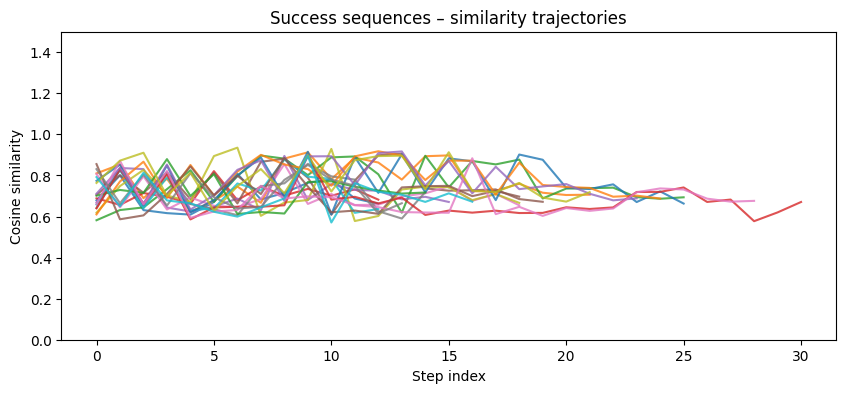

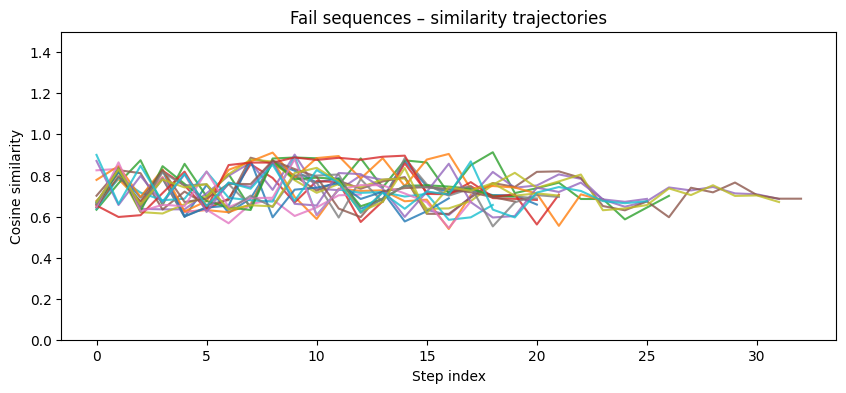

In [31]:
def collect_similarity_sequences(model, dataset, max_seqs=10, min_len=15):
    success_seqs = []
    fail_seqs = []

    for i in range(len(dataset)):
        seq, label = dataset[i]

        non_zero = (seq != 0).any(dim=1)
        if not non_zero.any():
            continue

        clean_seq = seq[non_zero.nonzero()[0, 0]:]

        if len(clean_seq) < min_len:
            continue

        sims = []
        for pos in range(5, len(clean_seq) - 1):
            context = clean_seq[:pos+1]
            target = clean_seq[pos+1]
            sims.append(get_prediction_similarity(model, context, target))

        if not sims:
            continue

        if label[1] == 1 and len(success_seqs) < max_seqs:
            success_seqs.append(sims)
        elif label[1] != 1 and len(fail_seqs) < max_seqs:
            fail_seqs.append(sims)

        if len(success_seqs) >= max_seqs and len(fail_seqs) >= max_seqs:
            break

    return success_seqs, fail_seqs

success_trajs, fail_trajs = collect_similarity_sequences(
    model, test_dataset, max_seqs=20
)

# --- Success ---
plt.figure(figsize=(10, 4))
for s in success_trajs:
    plt.plot(s, alpha=0.8)
plt.xlabel("Step index")
plt.ylabel("Cosine similarity")
plt.title("Success sequences – similarity trajectories")
plt.ylim(0, 1.5)
plt.show()

# --- Fail ---
plt.figure(figsize=(10, 4))
for f in fail_trajs:
    plt.plot(f, alpha=0.8)
plt.xlabel("Step index")
plt.ylabel("Cosine similarity")
plt.title("Fail sequences – similarity trajectories")
plt.ylim(0, 1.5)
plt.show()

In [25]:
K = 3  # number of final real steps to evaluate

def late_window_variances(sim_sequences, K):
    vars_ = []
    for sims in sim_sequences:
        # remove right-padding
        sims = sims[~np.isnan(sims)]
        if len(sims) < K:
            continue
        late = sims[-K:]
        vars_.append(np.var(late))
    return np.array(vars_)

success_vars = late_window_variances(success_sims, K)
fail_vars    = late_window_variances(fail_sims, K)

print("Success variance mean:", success_vars.mean())
print("Fail variance mean:", fail_vars.mean())


Success variance mean: 0.0004365505
Fail variance mean: 0.0019083234


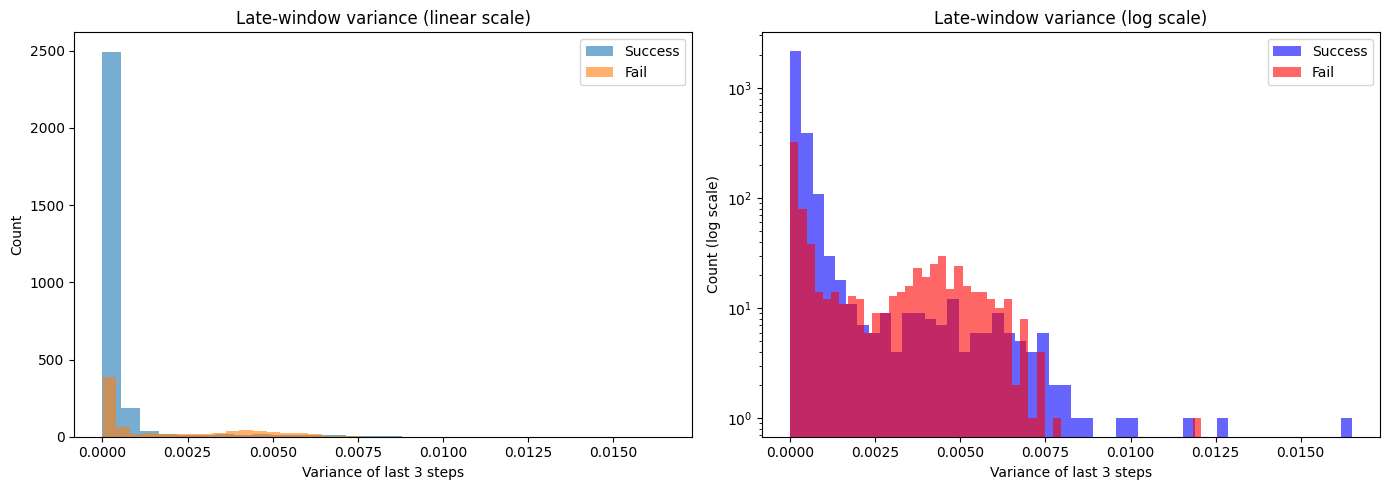

In [26]:
plt.figure(figsize=(14, 5))

# Left plot - linear scale
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
plt.hist(success_vars, bins=30, alpha=0.6, label='Success')
plt.hist(fail_vars, bins=30, alpha=0.6, label='Fail')
plt.xlabel(f'Variance of last {K} steps')
plt.ylabel('Count')
plt.title(f'Late-window variance (linear scale)')
plt.legend()

# Right plot - log scale
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
plt.hist(success_vars, bins=50, alpha=0.6, label='Success', color='blue')
plt.hist(fail_vars, bins=50, alpha=0.6, label='Fail', color='red')
plt.yscale('log')
plt.xlabel(f'Variance of last {K} steps')
plt.ylabel('Count (log scale)')
plt.title(f'Late-window variance (log scale)')
plt.legend()

plt.tight_layout()  # Adjust spacing between plots
plt.show()

In [30]:
# testing thresholds

def eval_thresholds(success_vars, fail_vars, thresholds):
    results = []

    for t in thresholds:
        # Predictions
        success_pred_anom = success_vars > t
        fail_pred_anom    = fail_vars > t

        TP = fail_pred_anom.sum()                    # fail → anomaly
        FN = (~fail_pred_anom).sum()                 # fail → normal
        FP = success_pred_anom.sum()                 # success → anomaly
        TN = (~success_pred_anom).sum()              # success → normal

        detection_rate = TP / (TP + FN + 1e-8)
        false_alarm    = FP / (FP + TN + 1e-8)

        results.append((t, detection_rate, false_alarm))

    return results

thresholds = np.arange(0, 0.0006, 0.00005)

results = eval_thresholds(success_vars, fail_vars, thresholds)
print("thr\tDR\tFAR")
for t, dr, far in results[:20:]:  # every 5th for readability
    print(f"{t:.4f}\t{dr:.3f}\t{far:.3f}")

thr	DR	FAR
0.0000	1.000	1.000
0.0001	0.857	0.783
0.0001	0.773	0.618
0.0002	0.695	0.491
0.0002	0.636	0.399
0.0003	0.597	0.322
0.0003	0.561	0.264
0.0003	0.528	0.225
0.0004	0.526	0.191
0.0005	0.514	0.161
0.0005	0.500	0.140
0.0006	0.493	0.127


In [19]:
import numpy as np

# threshold = 0.0003  # variance threshold for anomaly

ts = np.arange(0.011, 0.012, 0.0001)

for t in ts:
    threshold = t
    # success_vars and fail_vars are 1D arrays of late-window variances
    success_pred_anomaly = success_vars > threshold  # high variance → anomaly
    fail_pred_anomaly    = fail_vars    > threshold

    # Confusion matrix components
    TP = np.sum(fail_pred_anomaly)              # fail correctly flagged
    FN = np.sum(~fail_pred_anomaly)             # fail missed
    FP = np.sum(success_pred_anomaly)           # success falsely flagged
    TN = np.sum(~success_pred_anomaly)          # success correctly normal

    confusion_matrix = np.array([
        [TN, FP],   # Actual Success
        [FN, TP]    # Actual Fail
    ])

    # Optional rates
    FAR = FP / (FP + TN + 1e-8)
    DR  = TP / (TP + FN + 1e-8)

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print(f"Overall accuracy: {accuracy:.3f}")

Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777
Overall accuracy: 0.777


In [20]:
import numpy as np

threshold = 0.0115  # variance threshold for anomaly

# success_vars and fail_vars are 1D arrays of late-window variances
success_pred_anomaly = success_vars > threshold  # high variance → anomaly
fail_pred_anomaly    = fail_vars    > threshold

# Confusion matrix components
TP = np.sum(fail_pred_anomaly)              # fail correctly flagged
FN = np.sum(~fail_pred_anomaly)             # fail missed
FP = np.sum(success_pred_anomaly)           # success falsely flagged
TN = np.sum(~success_pred_anomaly)          # success correctly normal

confusion_matrix = np.array([
    [TN, FP],   # Actual Success
    [FN, TP]    # Actual Fail
])

print("Confusion Matrix (rows=actual, cols=predicted)")
print("            Pred Normal   Pred Anomaly")
print(f"Success     {TN:6d}        {FP:6d}")
print(f"Fail        {FN:6d}        {TP:6d}")

# Optional rates
FAR = FP / (FP + TN + 1e-8)
DR  = TP / (TP + FN + 1e-8)

print("\nRates:")
print(f"False Alarm Rate: {FAR:.3f}")
print(f"Detection Rate:   {DR:.3f}")

accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Overall accuracy: {accuracy:.3f}")

Confusion Matrix (rows=actual, cols=predicted)
            Pred Normal   Pred Anomaly
Success       2854             3
Fail           814             0

Rates:
False Alarm Rate: 0.001
Detection Rate:   0.000
Overall accuracy: 0.777


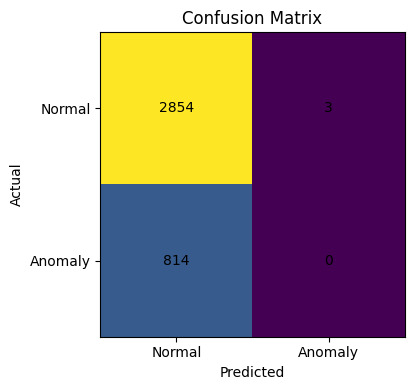

In [21]:
# confusion matrix

import matplotlib.pyplot as plt

labels = ["Normal", "Anomaly"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion_matrix)

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(["Normal", "Anomaly"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# Annotate cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion_matrix[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()